# Projeção detalhada da capitalização do Fundo Soberano do RJ — **2026**
---
### Sumário do método
1. **Receita** de petróleo/gás projetada para 2025 e 2026 (produção ANP × curva a termo do Brent).
2. **Aporte ao fundo** = 30% do *incremento* anual da base (PE + royalties excedentes) — regra da **LC 200/2022**.
3. **Dedução final de 6%** sobre a receita anual (média histórica das deduções — justificada no Passo 3).
4. **Escolha do método** de rendimento mensal (taxa equivalente, regime composto).
5. **Simulação mês a mês** da capitalização.
6. **Resultado final** e conclusão.

## Fontes e premissas (do *dashboard*)

| Item | Valor | Fonte |
|---|---|---|
| Patrimônio inicial (jan/2026) | **R$ 2,045 bi** | Dashboard (input manual) |
| Produção de óleo e gás (Campos + Santos, mar) | previsão anual | **ANP/SDP** `previsao-producao.csv` |
| Preço do petróleo | **curva a termo do Brent** (Yahoo `BZ*.NYM`) | Dashboard |
| Câmbio USD/BRL | **diário** (`USDBRL=X`) | Dashboard |
| Regra de repartição (Royalties/PE) | Lei 9.478/97, 7.990/89 | Planilha `royalties_calculo.xlsx` |
| Regra de aporte ao fundo | **30% do incremento** (PE + royalties excedentes) | **LC 200/2022** |
| Realizado (calibração/validação) | Tesouro-RJ | `receitas_petroleo_realizado.csv` |
| Selic 2026 esperada | **14% a.a.** | Expectativa (default do dashboard) |
| Saque dos rendimentos | **80%** | Dashboard |
| Dedução final | **6%** | Média das deduções anuais (Passo 3) |

> Os valores de mercado (Brent, câmbio) são os do dashboard na data de referência (jul/2026).
> Fixá-los aqui deixa o caderno **reprodutível**; o dashboard os atualiza ao vivo.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (9, 4.2), 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.axisbelow': True})

# ============ PARÂMETROS (fontes: dashboard / LC 200-2022 / ANP / SEFAZ) ============
PATRIMONIO_INICIAL   = 2.045e9    # R$  (dashboard)
SELIC_2026           = 0.14       # a.a. (expectativa; default do dashboard)
PCT_SAQUE            = 0.80       # do rendimento (dashboard)
PCT_APORTE_INCREMENTO= 0.30       # LC 200/2022: 30% do incremento
DEDUCAO_FINAL        = 0.06       # média das deduções totais anuais (justificada no Passo 3)

# Mercado — do dashboard, ref. jul/2026 (curva a termo BZ*.NYM, câmbio diário)
BRENT_2025_USD, BRENT_2026_USD = 75.4, 75.6   # US$/bbl
USDBRL     = 5.14                              # R$/US$ (USDBRL=X, diário)
GAS_BRL_M3 = 0.60                              # R$/m³  (Henry Hub convertido / dashboard)
M3_TO_BBL  = 6.28981                           # 1 m³ de petróleo = 6,28981 bbl (ANP)
print('Parâmetros carregados. Selic 2026 =', f'{SELIC_2026:.0%}',
      '| saque =', f'{PCT_SAQUE:.0%}', '| dedução =', f'{DEDUCAO_FINAL:.0%}')

Parâmetros carregados. Selic 2026 = 14% | saque = 80% | dedução = 6%


## Passo 1 — Receita de petróleo/gás projetada (2025 e 2026)

Reproduz o cálculo do dashboard: para cada ano,

$$\text{valor da produção} = V_{\text{óleo}}\,(\text{bbl}) \times P_{\text{Brent}}\,(\text{R\$/bbl}) + V_{\text{gás}}\,(\text{m}^3)\times P_{\text{gás}}$$

Sobre esse valor aplica-se a **regra de repartição vigente** (RJ recebe 30% da parcela de
5% e 22,5% do excedente acima de 5%). A **Participação Especial (PE)** é estimada pela
**regressão linear** `PE = a + b·Royalties`, calibrada na série histórica da SEFAZ (o
mesmo método do dashboard).

A base que interessa à LC 200/2022 é **PE + royalties excedentes (>5%)** — exclui a
parcela mínima de 5%.

In [4]:
# --- Produção ANP (Campos + Santos, mar) ---
prod = pd.read_csv('previsao-producao.csv', sep=',', decimal=',', thousands='.', encoding='utf-8-sig')
prod.columns = [c.strip() for c in prod.columns]
mar = prod[(prod['BACIA'].isin(['Campos', 'Santos'])) & (prod['AMBIENTE'] == 'MAR')]
vol_oleo = mar.groupby('ANO')['VOLUME PETRÓLEO'].sum() * M3_TO_BBL   # bbl/ano
vol_gas  = mar.groupby('ANO')['VOLUME GÁS'].sum() * 1000             # m³/ano  (mil m³ -> m³)

# --- Regressão PE ~ Royalties (série histórica SEFAZ) ---
h = pd.read_csv('serie_historica_receitas_2015-2026.csv', sep=';', decimal=',', encoding='utf-8-sig')
h['v'] = pd.to_numeric(h['Receita Realizada (mês)'], errors='coerce').fillna(0)
nat = h['Natureza da Receita (Tit. NR)'].fillna('').str.lower()
ded = nat.str.contains('dedu')
pe_hist  = h[nat.str.contains('participa') & nat.str.contains('espec') & ~ded].groupby('Ano')['v'].sum()
roy_hist = h[nat.str.contains('royal') & ~ded].groupby('Ano')['v'].sum()
b_pe, a_pe = np.polyfit(roy_hist.values, pe_hist.values, 1)
print(f'Regressão PE = {a_pe/1e9:.2f} + {b_pe:.3f} x Royalties  (R$ bi)')

def receita(ano, brent_usd):
    valor = vol_oleo[ano] * brent_usd * USDBRL + vol_gas[ano] * GAS_BRL_M3
    parcela_exc = (0.10 - 0.05) * valor          # excedente acima de 5% (alíquota 10%)
    rj_exc = parcela_exc * 0.225                 # cota RJ no excedente
    rj_5   = 0.05 * valor * 0.30                 # cota RJ na parcela de 5%
    roy = rj_5 + rj_exc
    pe  = max(a_pe + b_pe * roy, 0.0)
    return {'valor': valor, 'roy': roy, 'pe': pe, 'rj_exc': rj_exc,
            'base_lc': pe + rj_exc, 'total': roy + pe}

r25 = receita(2025, BRENT_2025_USD)
r26 = receita(2026, BRENT_2026_USD)
tab_rec = pd.DataFrame({
    '2025': [r25['valor']/1e9, r25['roy']/1e9, r25['pe']/1e9, r25['base_lc']/1e9, r25['total']/1e9],
    '2026': [r26['valor']/1e9, r26['roy']/1e9, r26['pe']/1e9, r26['base_lc']/1e9, r26['total']/1e9],
}, index=['Valor da produção', 'Royalties RJ', 'Part. Especial RJ',
          'Base LC (PE + excedente)', 'Total RJ (Roy + PE)']).round(2)
print('\nReceitas projetadas (R$ bi):')
tab_rec

Regressão PE = 1.73 + 1.035 x Royalties  (R$ bi)

Receitas projetadas (R$ bi):


,2025,2026
Valor da produção,549.42,624.06
Royalties RJ,14.42,16.38
Part. Especial RJ,16.66,18.69
Base LC (PE + excedente),22.84,25.71
Total RJ (Roy + PE),31.08,35.07


## Passo 2 — Aporte ao fundo pela **LC 200/2022**

A LC 200/2022 alimenta o fundo com **30% do aumento (incremento) da arrecadação** com
Participação Especial + royalties excedentes — **não** um percentual da receita cheia.
Logo:

$$\text{Aporte}_{2026} = 30\% \times \max\!\big(\text{Base}_{2026} - \text{Base}_{2025},\ 0\big)$$

O ano anterior (2025) é a **âncora** do incremento. Validamos o nível contra o
**realizado do Tesouro** e comparamos com o número oficial da SEFAZ.

In [5]:
bl25 = r25['base_lc'];  bl26 = r26['base_lc'];  tot25 = r25['total']
incremento   = bl26 - bl25
aporte_bruto = PCT_APORTE_INCREMENTO * max(incremento, 0.0)
print('Base LC 2025 ........ R$ {:.2f} bi'.format(bl25/1e9))
print('Base LC 2026 ........ R$ {:.2f} bi'.format(bl26/1e9))
print('Incremento .......... R$ {:.2f} bi'.format(incremento/1e9))
print('Aporte BRUTO (30%) .. R$ {:.3f} bi'.format(aporte_bruto/1e9))

# --- Validação de nível com o realizado do Tesouro ---
rt = pd.read_csv('receitas_petroleo_realizado.csv', sep=';', decimal=',', thousands='.', encoding='latin-1')
rt.columns = [c.strip() for c in rt.columns]
rt['ano'] = pd.to_datetime(rt['Posição'], format='%d/%m/%Y', errors='coerce').dt.year
rt['v']   = pd.to_numeric(rt['Valor Receita Realizada'], errors='coerce').fillna(0)
nmt = rt['Nome Sub Alinea'].fillna('').str.lower()
real = rt[nmt.str.contains('royalt') | nmt.str.contains('participa')].groupby('ano')['v'].sum()
real25 = real.get(2025)
print('\nCross-check de nivel:')
print('  Realizado Tesouro 2025 = R$ {:.2f} bi  (modelo total 2025 = R$ {:.1f} bi)'.format(real25/1e9, tot25/1e9))
print('  Referencia oficial SEFAZ (4a Revisao) p/ aporte 2026 ~ R$ 1,5 bi')

Base LC 2025 ........ R$ 22.84 bi
Base LC 2026 ........ R$ 25.71 bi
Incremento .......... R$ 2.87 bi
Aporte BRUTO (30%) .. R$ 0.860 bi

Cross-check de nivel:
  Realizado Tesouro 2025 = R$ 25.82 bi  (modelo total 2025 = R$ 31.1 bi)
  Referencia oficial SEFAZ (4a Revisao) p/ aporte 2026 ~ R$ 1,5 bi


## Passo 3 — **Dedução final de 6%**

Aplica-se uma **dedução de 6% sobre a receita anual** destinada ao fundo. Esse valor é a
**média das deduções totais anuais** observadas — deduções (FUNDEB, restituições, etc.)
medidas **sobre o total (royalties + PE)**, e não só sobre os royalties.

Calculamos a taxa histórica na série da SEFAZ. Os anos **2019–2020** são *outliers*
(deduções extraordinárias de PE, ~48%, por ajustes retroativos) e são descartados; o
regime normal recente (**2021–2025**) fica em torno de **6%**.

Taxa de dedução sobre (Royalties + PE), % ao ano:
Ano
2015    19.0
2016    40.9
2017     5.4
2018     4.0
2019    48.4
2020    49.6
2021     5.7
2022     5.5
2023     6.0
2024     6.4
2025     6.7
2026     8.1

Média 2021-2025 (regime normal) = 6.1%   -> adotamos 6%
Mediana de todos os anos       = 6.5%


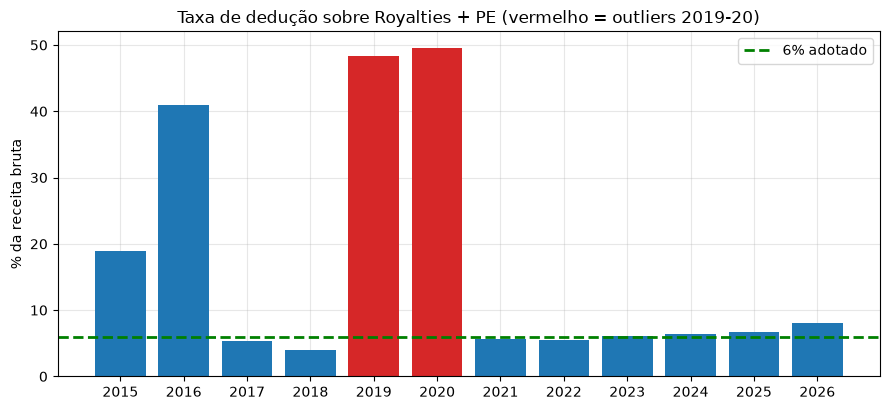


Aporte BRUTO ....... R$ 0.860 bi
(-) dedução 6% .... R$ 0.052 bi
= Aporte LÍQUIDO ... R$ 0.809 bi


In [6]:
bruto_tot = h[(nat.str.contains('participa') & nat.str.contains('espec') | nat.str.contains('royal')) & ~ded].groupby('Ano')['v'].sum()
deduc_tot = h[(nat.str.contains('participa') & nat.str.contains('espec') | nat.str.contains('royal')) & ded].groupby('Ano')['v'].sum().abs()
taxa = (deduc_tot / bruto_tot * 100).dropna()
recentes = taxa.reindex([2021, 2022, 2023, 2024, 2025])
print('Taxa de dedução sobre (Royalties + PE), % ao ano:')
print(taxa.round(1).to_string())
print(f'\nMédia 2021-2025 (regime normal) = {recentes.mean():.1f}%   -> adotamos {DEDUCAO_FINAL:.0%}')
print(f'Mediana de todos os anos       = {taxa.median():.1f}%')

fig, ax = plt.subplots()
cores = ['#d62728' if a in (2019, 2020) else '#1f77b4' for a in taxa.index]
ax.bar(taxa.index.astype(int).astype(str), taxa.values, color=cores)
ax.axhline(DEDUCAO_FINAL*100, color='green', ls='--', lw=2, label=f'6% adotado')
ax.set_title('Taxa de dedução sobre Royalties + PE (vermelho = outliers 2019-20)')
ax.set_ylabel('% da receita bruta'); ax.legend()
plt.tight_layout(); plt.show()

aporte_liquido = aporte_bruto * (1 - DEDUCAO_FINAL)
print(f'\nAporte BRUTO ....... R$ {aporte_bruto/1e9:.3f} bi')
print(f'(-) dedução {DEDUCAO_FINAL:.0%} .... R$ {aporte_bruto*DEDUCAO_FINAL/1e9:.3f} bi')
print(f'= Aporte LÍQUIDO ... R$ {aporte_liquido/1e9:.3f} bi')

## Passo 4 — **Escolha do método** de rendimento mensal

A carteira (títulos indexados à Selic, tipo LFT) rende em **regime de juros compostos**.
Ao converter a taxa **anual** em **mensal**, há dois caminhos:

- **Taxa proporcional (juros simples):** $i_m = i_a / 12$ — **incorreta** aqui, pois ignora
  os juros sobre juros (subestima a capitalização).
- **Taxa equivalente (juros compostos):** $i_m = (1+i_a)^{1/12} - 1$ — **correta**, pois ao
  compor 12 meses reproduz exatamente a taxa anual efetiva.

Adotamos a **taxa equivalente**, que é o padrão de renda fixa/Selic. (O método mais fino
seria compor a Selic em dias úteis — 252 —; a taxa equivalente mensal é uma aproximação
fiel para a simulação mensal.)

In [7]:
i_prop  = SELIC_2026 / 12
i_equiv = (1 + SELIC_2026)**(1/12) - 1
print(f'Taxa proporcional (simples): {i_prop*100:.4f}%/mês  ->  12 meses compostos = {((1+i_prop)**12-1)*100:.2f}%')
print(f'Taxa equivalente  (composta): {i_equiv*100:.4f}%/mês  ->  12 meses compostos = {((1+i_equiv)**12-1)*100:.2f}%  (= Selic {SELIC_2026:.0%})')
print('\n>> Método escolhido: TAXA EQUIVALENTE (regime composto).')
i_m = i_equiv

Taxa proporcional (simples): 1.1667%/mês  ->  12 meses compostos = 14.93%
Taxa equivalente  (composta): 1.0979%/mês  ->  12 meses compostos = 14.00%  (= Selic 14%)

>> Método escolhido: TAXA EQUIVALENTE (regime composto).


## Passo 5 — Simulação **mês a mês** de 2026

Dinâmica mensal (para cada mês $m$):

- Rendimento: $R_m = \text{saldo}_m \times i_m$
- Saque: $S_m = R_m \times 30\%$ (revertido a outros fins) · Retido: $R_m - S_m$
- Aporte mensal: aporte líquido anual ÷ 12 (distribuído uniformemente ao longo do ano)
- Saldo ao fim: $\text{saldo}_{m+1} = \text{saldo}_m + (R_m - S_m) + \text{aporte}_m$

*(As receitas de petróleo entram ao longo do ano; distribuí-las em 12 parcelas é uma
aproximação — alternativas: sazonal ou repasse único no fim do ano.)*

In [8]:
meses = pd.period_range('2026-01', periods=12, freq='M')
aporte_mes = aporte_liquido / 12
saldo = PATRIMONIO_INICIAL
linhas = []
for m in meses:
    rend   = saldo * i_m
    saque  = rend * PCT_SAQUE
    retido = rend - saque
    saldo_fim = saldo + retido + aporte_mes
    linhas.append([str(m), saldo, rend, saque, retido, aporte_mes, saldo_fim])
    saldo = saldo_fim

sim = pd.DataFrame(linhas, columns=['Mês', 'Saldo início', 'Rendimento', 'Saque',
                                    'Retido', 'Aporte', 'Saldo fim'])
disp = sim.copy()
for c in ['Saldo início', 'Rendimento', 'Saque', 'Retido', 'Aporte', 'Saldo fim']:
    disp[c] = (disp[c] / 1e9).round(4)
print('Simulação mensal 2026 (R$ bilhões):')
disp

Simulação mensal 2026 (R$ bilhões):


,Mês,Saldo início,Rendimento,Saque,Retido,Aporte,Saldo fim
0,2026-01,2.0450,0.0225,0.0180,0.0045,0.0674,2.1169
1,2026-02,2.1169,0.0232,0.0186,0.0046,0.0674,2.1889
2,2026-03,2.1889,0.0240,0.0192,0.0048,0.0674,2.2611
3,2026-04,2.2611,0.0248,0.0199,0.0050,0.0674,2.3335
4,2026-05,2.3335,0.0256,0.0205,0.0051,0.0674,2.4060
5,2026-06,2.4060,0.0264,0.0211,0.0053,0.0674,2.4787
6,2026-07,2.4787,0.0272,0.0218,0.0054,0.0674,2.5515
7,2026-08,2.5515,0.0280,0.0224,0.0056,0.0674,2.6245
8,2026-09,2.6245,0.0288,0.0231,0.0058,0.0674,2.6977
9,2026-10,2.6977,0.0296,0.0237,0.0059,0.0674,2.7710


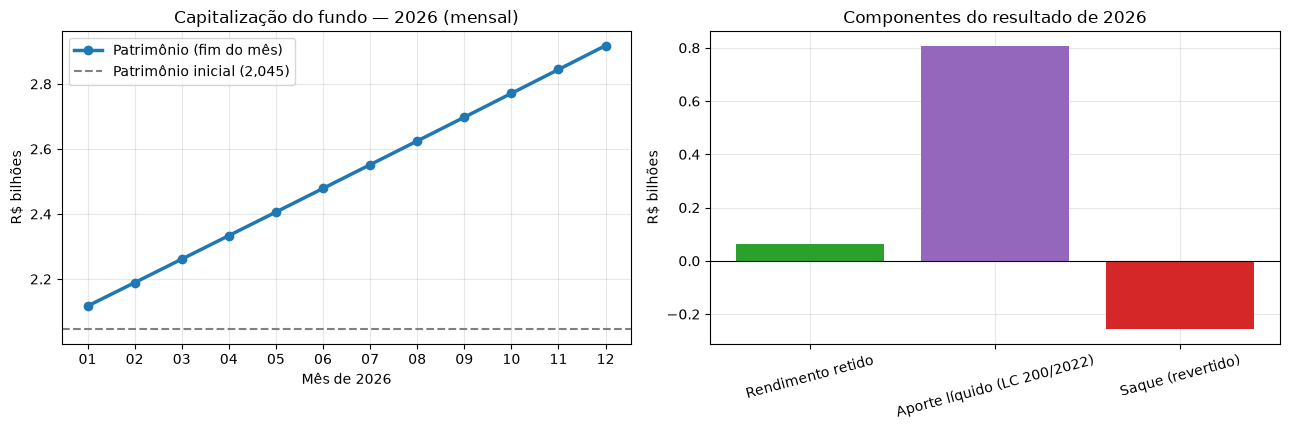

In [9]:
# ---- Gráficos ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

# (a) Capitalização mensal
x = list(range(1, 13))
ax1.plot(x, sim['Saldo fim']/1e9, 'o-', color='#1f77b4', lw=2.5, label='Patrimônio (fim do mês)')
ax1.axhline(PATRIMONIO_INICIAL/1e9, color='gray', ls='--', label='Patrimônio inicial (2,045)')
ax1.set_title('Capitalização do fundo — 2026 (mensal)')
ax1.set_xlabel('Mês de 2026'); ax1.set_ylabel('R$ bilhões')
ax1.set_xticks(x); ax1.set_xticklabels([str(m)[-2:] for m in meses]); ax1.legend()

# (b) Composição do crescimento no ano
comp = {'Rendimento retido': sim['Retido'].sum()/1e9,
        'Aporte líquido (LC 200/2022)': sim['Aporte'].sum()/1e9,
        'Saque (revertido)': -sim['Saque'].sum()/1e9}
ax2.bar(comp.keys(), comp.values(),
        color=['#2ca02c', '#9467bd', '#d62728'])
ax2.axhline(0, color='k', lw=0.8)
ax2.set_title('Componentes do resultado de 2026')
ax2.set_ylabel('R$ bilhões')
ax2.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

## Passo 6 — Resultado final e conclusão

In [11]:
p0 = PATRIMONIO_INICIAL/1e9
pf = sim['Saldo fim'].iloc[-1]/1e9
rend_tot = sim['Rendimento'].sum()/1e9
saque_tot = sim['Saque'].sum()/1e9
print('='*56)
print('  FUNDO SOBERANO DO RJ — PROJEÇÃO 2026 (resumo)')
print('='*56)
print(f'  Patrimônio inicial (jan/26) ....... R$ {p0:6.3f} bi')
print(f'  (+) Rendimento bruto (Selic) ...... R$ {rend_tot:6.3f} bi')
print(f'  (-) Saque (80% do rendimento) ..... R$ {saque_tot:6.3f} bi')
print(f'  (+) Aporte líquido (LC 200/2022) .. R$ {aporte_liquido/1e9:6.3f} bi')
print(f'      (aporte bruto {aporte_bruto/1e9:.2f} - dedução 6%)')
print('  ' + '-'*52)
print(f'  = Patrimônio final (dez/26) ....... R$ {pf:6.3f} bi')
print(f'    Crescimento no ano ................ {(pf/p0-1)*100:+.1f}%')
print('='*56)
print('\nComo se chegou ao valor final:')
print('  1) Receita 2026 (producao ANP x Brent a termo) -> base LC {:.1f} bi'.format(bl26/1e9))
print('  2) Aporte = 30% do incremento (LC 200/2022) = {:.2f} bi'.format(aporte_bruto/1e9))
print('  3) Deducao final 6% (media historica) -> aporte liquido {:.2f} bi'.format(aporte_liquido/1e9))
print('  4) Rendimento mensal pela taxa equivalente ({:.4f}%/mes), saque 80%'.format(i_m*100))
print('  5) Capitalizacao mes a mes -> R$ {:.2f} bi em dez/2026'.format(pf))

  FUNDO SOBERANO DO RJ — PROJEÇÃO 2026 (resumo)
  Patrimônio inicial (jan/26) ....... R$  2.045 bi
  (+) Rendimento bruto (Selic) ...... R$  0.322 bi
  (-) Saque (80% do rendimento) ..... R$  0.258 bi
  (+) Aporte líquido (LC 200/2022) .. R$  0.809 bi
      (aporte bruto 0.86 - dedução 6%)
  ----------------------------------------------------
  = Patrimônio final (dez/26) ....... R$  2.918 bi
    Crescimento no ano ................ +42.7%

Como se chegou ao valor final:
  1) Receita 2026 (producao ANP x Brent a termo) -> base LC 25.7 bi
  2) Aporte = 30% do incremento (LC 200/2022) = 0.86 bi
  3) Deducao final 6% (media historica) -> aporte liquido 0.81 bi
  4) Rendimento mensal pela taxa equivalente (1.0979%/mes), saque 80%
  5) Capitalizacao mes a mes -> R$ 2.92 bi em dez/2026


### Conclusão

Partindo de **R$ 2,045 bi**, o fundo termina 2026 capitalizado pela combinação de
**rendimento retido da Selic** (20% do ano de yield, já que se saca 30% do rendimento
composto) e do **aporte líquido da LC 200/2022** (30% do incremento da arrecadação,
após a dedução de 6%). O crescimento é **sustentável** — nunca se toca no principal.

**Notas de transparência (verificação):**
- O **aporte depende do incremento** de receita (2026 vs 2025), sensível às premissas de
  preço/câmbio; nosso número é **conservador** frente ao oficial (~R$ 1,5 bi da SEFAZ),
  porque a curva a termo do Brent e o câmbio de 2026 são próximos aos de 2025 — o aumento
  é quase todo de **produção** (rampa de Santos).
- A **dedução de 6%** é a média das deduções totais recentes (2021–2025), sobre a base
  Royalties + PE; 2019–2020 foram excluídos por serem *outliers*.
- A distribuição uniforme do aporte em 12 meses é uma simplificação didática.
- Aportes de **TAC e leilões** (50%, LC 200/2022) não estão projetados.